In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal, osr
from matplotlib.colors import ListedColormap
import contextily as cx

# Enable GDAL exceptions for robust debugging
gdal.UseExceptions()

###
### 📡 5G Rooftop Coverage & Viewshed Analyzer
This repository contains a procedural GIS and wireless propagation engine designed to analyze line-of-sight (LoS) visibility and 5G C-Band signal coverage from a specific macro cell site.

By combining Digital Elevation Models (DEM) with 3GPP propagation standards, the script automates coordinate reprojection, extracts precise terrain profiles, and generates actionable viewshed maps for RF planning.
### 🚀 Key Features
- Automated CRS Reprojection: Converts geographic coordinates (WGS84) and raw DEM data into local metric UTM coordinates for precise spatial calculations.
- Line-of-Sight Simulation: Computes true visibility between a 35-meter gNodeB tower and 2-meter User Equipment (UE) within a 2 km radius.
- Link Budget Integration: Dynamically calculates Link Budget and Equivalent Isotropically Radiated Power (EIRP) using the formula:
- 
$$\text{Total EIRP} = \text{Tx Power (40 dBm)} + \text{Antenna Gain (12 dBi)} - \text{Cable Loss (0.5 dB)}$$

- Clutter Tuning: Built-in hooks for terrain shadow penalties to transition seamlessly from ideal environments to dense urban layouts.
### 📈 Planned Outputs
- dem_utm_aligned.tif: The reprojected, clipped, and aligned DEM grid.
- tower_viewshed.tif: A high-fidelity raster map showing binary visibility and coverage thresholds from the macro site.

In [2]:
# ==========================================
# 1. CONFIGURATION & PROPAGATION TUNING
# ==========================================
print("--- Professional 5G Rooftop Coverage Analyzer (Procedural) ---")

raw_dem_path = r"C:\Users\abdul\Downloads\DEM\n21_e039_1arc_v3.tif"
utm_dem_path = "dem_utm_aligned.tif"
output_viewshed_path = "tower_viewshed.tif"

# Core Site Coordinates (WGS84)
obs_lon, obs_lat = 39.244606, 21.483473  
target_lon, target_lat = 39.2490, 21.4800 

obs_height = 35.0         # Height above ground (m)
target_height = 2.0       # UE Height above ground (m)
max_distance_m = 2000.0   # Coverage/District analysis radius (m)

# Link Budget & Physics Parameters
frequency_mhz = 3500.0    # C-Band 5G
tx_power_dbm = 40.0
antenna_gain_dbi = 12.0
cable_loss_db = 0.5
total_eirp = tx_power_dbm + antenna_gain_dbi - cable_loss_db

# Propagation Clutter Adjustment (0.0 strictly respects standard 3GPP UMa)
terrain_shadow_penalty_db = 0.0 

if not os.path.exists(raw_dem_path):
    raise FileNotFoundError(f"Source DEM file not found at: {raw_dem_path}")

--- Professional 5G Rooftop Coverage Analyzer (Procedural) ---


### 🌍 Automatic UTM Zone Calculation

To perform accurate metric-based distance calculations (crucial for wireless signal propagation), the engine automatically determines the local Universal Transverse Mercator (UTM) zone and corresponding EPSG code using the base station's longitude and latitude.

- Dynamic Reprojection: Mathematically maps WGS84 geographic coordinates into the correct UTM Zone (EPSG:326XX for the Northern Hemisphere or EPSG:327XX for the Southern Hemisphere).

- Memory Management: Implements clean scoping and resets dataset pointers (None) to ensure exception-safe garbage collection when handling large raster files.

In [3]:
# ==========================================
# 2. AUTOMATIC UTM ZONE CALCULATION
# ==========================================
utm_zone = int(np.floor((obs_lon + 180) / 6) + 1)
is_northern = 1 if obs_lat >= 0 else 0
utm_epsg = 32600 + utm_zone if is_northern else 32700 + utm_zone
print(f"Targeting Projection Framework: EPSG:{utm_epsg} (UTM Zone {utm_zone}{'N' if is_northern else 'S'})")

# Scope datasets cleanly for exception-safe garbage collection
dem_ds = view_ds = slope_ds = aspect_ds = None

Targeting Projection Framework: EPSG:32637 (UTM Zone 37N)


### 🗺️ Spatial Alignment & Bounded Warping

This section handles the spatial transformations required to align raw geospatial data with the calculated local UTM framework.

- Coordinate Transformation: Uses GDAL/OSR to transform the project's geographic coordinates (WGS84, EPSG:4326) into precise metric coordinates based on the dynamically determined UTM zone (EPSG:utm_epsg).

- Optimized Bounding Box: Establishes a localized analysis buffer around the tower coordinates. It adds a 500 meter safety margin beyond the maximum analysis distance to account for edge terrain effects.

- Bounded Warping (gdal.Warp): Reprojects and clips the massive source DEM raster in a single step using bilinear resampling. Restricting the output strictly to the bounding box prevents processing over-allocation and saves CPU/memory resources.

In [4]:
# ==========================================
# 3. SPATIAL ALIGNMENT & BOUNDED WARPING
# ==========================================
print("\n--- Projecting Spatial Domain Reference Arrays ---")
src_srs = osr.SpatialReference()
src_srs.ImportFromEPSG(4326)
src_srs.SetAxisMappingStrategy(osr.OAMS_TRADITIONAL_GIS_ORDER)
    
dem_srs = osr.SpatialReference()
dem_srs.ImportFromEPSG(utm_epsg)
dem_srs.SetAxisMappingStrategy(osr.OAMS_TRADITIONAL_GIS_ORDER)
    
transform = osr.CoordinateTransformation(src_srs, dem_srs)
obs_x, obs_y, _ = transform.TransformPoint(obs_lon, obs_lat)
target_x, target_y, _ = transform.TransformPoint(target_lon, target_lat)
    
raw_ds = gdal.Open(raw_dem_path)
        
# Establish a clean analysis buffer box
margin = max_distance_m + 500.0
bbox = [obs_x - margin, obs_y - margin, obs_x + margin, obs_y + margin]
        
# Warp with direct output limits to prevent processing over-allocation
dem_ds = gdal.Warp(utm_dem_path, raw_ds, dstSRS=f'EPSG:{utm_epsg}', resampleAlg='bilinear', outputBounds=[bbox[0], bbox[1], bbox[2], bbox[3]])
raw_ds = None


--- Projecting Spatial Domain Reference Arrays ---


### 👁️ Viewshed Computation & Array Ingestion

This module executes the core visibility analysis and prepares the resulting spatial datasets for downstream RF propagation modeling.

- GDAL Viewshed Generation (gdal.ViewshedGenerate): Computes true line-of-sight visibility from the 35-meter gNodeB tower down to the 2-meter User Equipment (UE). It applies a standard earth curvature correction factor (refraction coefficient of $0.13$) across the maximum 2 km analysis radius.

- Array Ingestion & Masking: Reads the raw elevation and newly generated viewshed rasters into memory as NumPy arrays. It automatically identifies and masks NoData pixel values to protect statistical integrity during calculations.

- Sub-Pixel Alignment: Calculates exact coordinate offsets (x_off, y_off) between the elevation grid and the viewshed output. This ensures flawless pixel-to-pixel registration when extracting topographical profiles between the transmitter and the receiver.

In [5]:
# ==========================================
# 4. VIEWSHED COMPUTATION & ARRAY INGESTION
# ==========================================
print("\n--- Processing Line-Of-Sight Array Model ---")
band = dem_ds.GetRasterBand(1)
driver = gdal.GetDriverByName("GTiff")

gdal.ViewshedGenerate(
band, driver.GetName(), output_viewshed_path, [],
float(obs_x), float(obs_y), float(obs_height), float(target_height), 
    255.0, 0.0, 0.0, -9999.0, 0.13, 1, float(max_distance_m), None, None)

# Ingest structured arrays and configure masks properly
dem_full = dem_ds.GetRasterBand(1).ReadAsArray()
dem_gt = dem_ds.GetGeoTransform()
dem_rows, dem_cols = dem_full.shape
dem_extent = [dem_gt[0], dem_gt[0] + dem_cols * dem_gt[1], dem_gt[3] + dem_rows * dem_gt[5], dem_gt[3]]
    
nodata = dem_ds.GetRasterBand(1).GetNoDataValue()
dem_masked = np.ma.masked_equal(dem_full, nodata if nodata is not None else -9999.0)

view_ds = gdal.Open(output_viewshed_path)
view_data = view_ds.GetRasterBand(1).ReadAsArray()
view_gt = view_ds.GetGeoTransform()
v_rows, v_cols = view_data.shape
view_extent = [view_gt[0], view_gt[0] + v_cols * view_gt[1], view_gt[3] + v_rows * view_gt[5], view_gt[3]]

# Exact pixel alignment calculations for topographic extractions
x_off = int(round((view_gt[0] - dem_gt[0]) / dem_gt[1]))
y_off = int(round((view_gt[3] - dem_gt[3]) / dem_gt[5]))


--- Processing Line-Of-Sight Array Model ---


### 📉 Propagation Decay Math (3GPP UMa Vectorization)

This section contains the core RF physics engine. It bypasses slow iterative python loops, opting instead for highly optimized, fully vectorized NumPy operations to calculate 5G signal decay across the entire coverage grid using the 3GPP Urban Macro (UMa) propagation model.

- Coordinate Meshgrid Generation: Constructs absolute 2D metric coordinate matrices (X and Y) for every pixel in the viewshed, mapping out spatial relationships across the analysis area.

- 3D Euclidean Distance Mapping: Calculates both the 2D surface distance (d2D) and true 3D straight-line distance (d3D) between the transmitter and receiver, pinning minimum thresholds to 10 meters to prevent mathematical singularities.

- Dual-State Path Loss Engine: Automatically switches equations based on the GDAL viewshed visibility state (255 for Line-of-Sight, otherwise Non-Line-of-Sight):

    - Line-of-Sight (LoS): Computes path loss dynamically using the 3GPP breakpoint distance (dBP), shifting slope coefficients as signal vectors pass structural thresholds.

    - Non-Line-of-Sight (NLoS): Factors in structural obstructions alongside custom terrain shadow penalties.

- RSRP Calculation: Computes the Reference Signal Received Power (RSRP) by subtracting path loss from the total system EIRP. It clips values to an industry-standard receiver window (−120 dBm to −50 dBm) and masks out pixels beyond the 2 km maximum analysis radius using NaN boundaries.

In [6]:
# ==========================================
# 5. PROPAGATION DECAY MATH (3GPP UMa - NO FUNCTIONS)
# ==========================================
print("\n--- Resolving Signal Field Vector Equations ---")
x_coords = view_gt[0] + (np.arange(v_cols) + 0.5) * view_gt[1]
y_coords = view_gt[3] + (np.arange(v_rows) + 0.5) * view_gt[5]
X, Y = np.meshgrid(x_coords, y_coords)

dist_2d = np.sqrt((X - obs_x)**2 + (Y - obs_y)**2)
dist_3d = np.sqrt((X - obs_x)**2 + (Y - obs_y)**2 + (obs_height - target_height)**2)
    
f_ghz = frequency_mhz / 1000.0
h_bs_eff = obs_height - 1.0

d2_safe = np.maximum(dist_2d, 10.0)
d3_safe = np.maximum(dist_3d, 10.0)

# Vectorized 3GPP UMa Line-of-Sight Calculation
dbp = 4 * h_bs_eff * target_height * f_ghz * 1e9 / 3e8
pl1 = 32.4 + 21 * np.log10(d3_safe) + 20 * np.log10(f_ghz)
pl2 = 32.4 + 40 * np.log10(d3_safe) + 20 * np.log10(f_ghz) - 9.5 * np.log10(dbp**2 + (obs_height - target_height)**2)
pl_los = np.where(d2_safe <= dbp, pl1, pl2)

# Vectorized 3GPP UMa Non-Line-of-Sight Calculation
pl_nlos = 13.54 + 39.08 * np.log10(d2_safe) + 20 * np.log10(f_ghz) - 0.6 * (target_height - 1.5)

# Path Loss evaluation engine splitting conditions based on viewshed parameters
pl = np.where(view_data == 255, pl_los, pl_nlos + terrain_shadow_penalty_db)
    
rsrp = np.clip(total_eirp - pl, -120, -50)
rsrp = np.where(dist_2d <= max_distance_m, rsrp, np.nan)


--- Resolving Signal Field Vector Equations ---


### 🗺️ Visualization: District Signal Footprint Profile

This component handles map rendering and presentation, blending geospatial data layers into a highly polished, publishable analysis plot (telecom_5g_rooftop_rsrp.png).

- Multi-Layer Spatial Overlay: Uses Contextily (cx) and Matplotlib to dynamically stack three critical layers within the UTM bounding box bounds:
    - An online OpenStreetMap basemap (faded at 70% opacity for clear context).
    - The masked elevation terrain model (subtly layered underneath at 15% opacity).
    - The vectorized 5G RSRP coverage array rendered using a vibrant Spectral color map.

- Geospatial Reference Elements: Automatically plots a high-contrast black delta symbol (^) at the transmitter’s exact coordinates and projects a mathematically precise dashed circle marking the $2\text{ km}$ district coverage boundary.

- Telecom-Standard Legend & Scale: Re-maps raw decibel numbers into professional, industry-standard RF network performance brackets, clearly categorizing signal zones from -120 dBm (Outage) up to -80 dBm (Excellent).


--- Visualizing Map Overlays ---


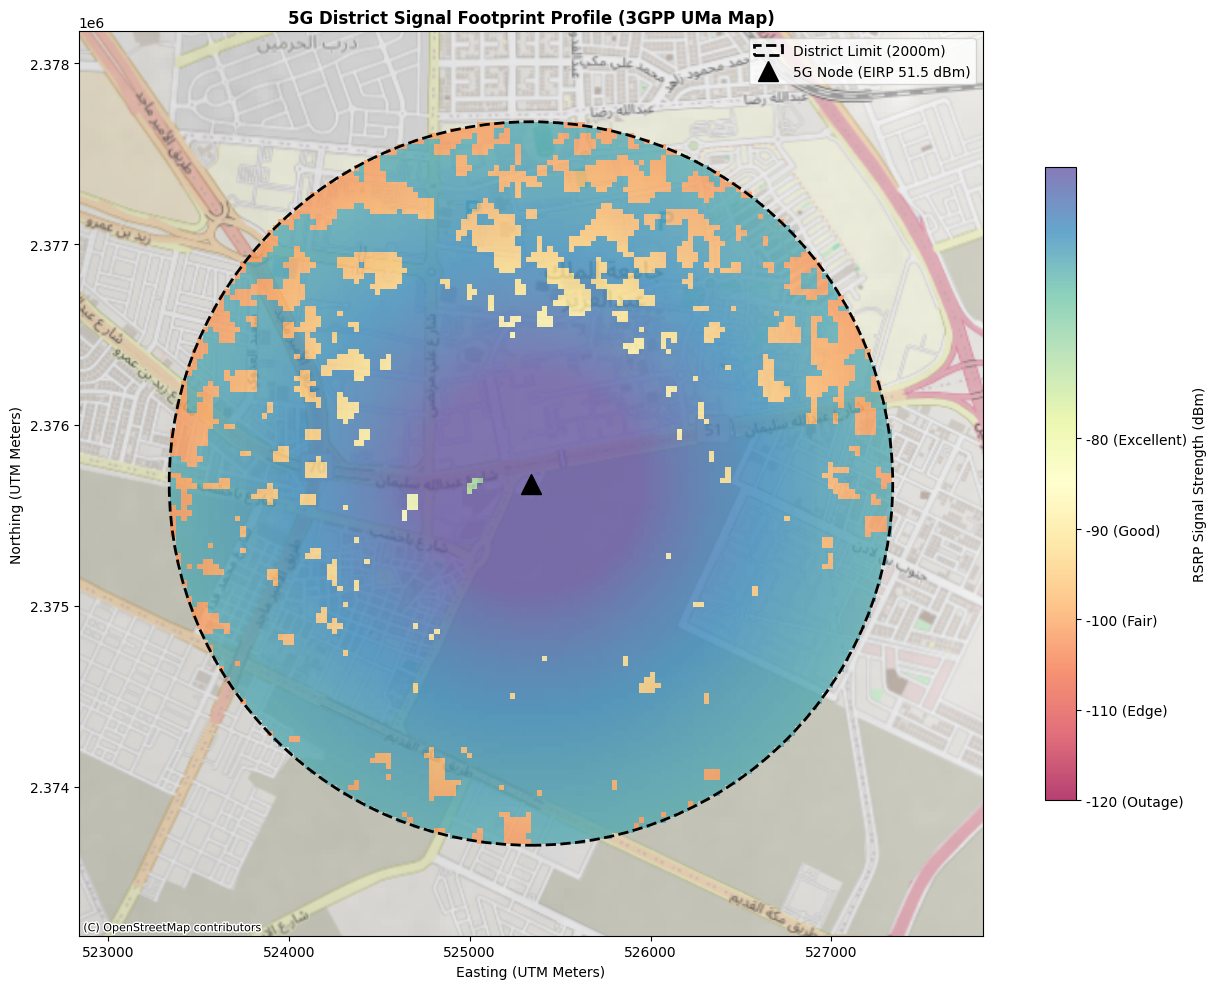

In [7]:
# ==========================================
# 6. PLOT 1: DISTRICT FOOTPRINT PROFILE
# ==========================================
print("\n--- Visualizing Map Overlays ---")
fig, ax = plt.subplots(figsize=(13, 10))
ax.set_xlim(bbox[0], bbox[2])
ax.set_ylim(bbox[1], bbox[3])
    
cx.add_basemap(ax, crs=dem_srs.ExportToProj4(), source=cx.providers.OpenStreetMap.Mapnik, alpha=0.7)
ax.imshow(dem_masked, cmap='gray', extent=dem_extent, alpha=0.15)
im = ax.imshow(rsrp, cmap='Spectral', extent=view_extent, alpha=0.75, vmin=-120, vmax=-50)
    
# Explicit Mathematical District Coverage Ring Boundary
district_boundary = plt.Circle((obs_x, obs_y), max_distance_m, color='black', fill=False, linestyle='--', linewidth=2, label=f'District Limit ({max_distance_m:.0f}m)')
ax.add_patch(district_boundary)
    
ax.plot(obs_x, obs_y, 'k^', markersize=14, label=f'5G Node (EIRP {total_eirp:.1f} dBm)')
cbar = plt.colorbar(im, label='RSRP Signal Strength (dBm)', shrink=0.7)
cbar.set_ticks([-120, -110, -100, -90, -80])
cbar.set_ticklabels(['-120 (Outage)', '-110 (Edge)', '-100 (Fair)', '-90 (Good)', '-80 (Excellent)'])
    
ax.set_title("5G District Signal Footprint Profile (3GPP UMa Map)", fontsize=12, fontweight='bold')
ax.set_xlabel("Easting (UTM Meters)")
ax.set_ylabel("Northing (UTM Meters)")
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig("telecom_5g_rooftop_rsrp.png", dpi=300)
plt.show() 

### 📐 Point-to-Point Link Geometry & Fresnel Clearance

This final module profiles a singular ray path between the transmitter ($\text{TX}$) and a target User Equipment ($\text{UE}$). It analyzes terrain clearance along the path and exports the cross-section diagram to telecom_5g_rooftop_fresnel.png.

- Dynamic Path Sampling: Linearly interpolates $200$ metric coordinates between the tower and target positions. It utilizes zero-fault index clipping to safely extract underlying terrain elevation from the raw DEM matrix.

- Effective Earth Curvature ($4/3$ Earth Model): Corrects standard DEM values using the industry-standard $4/3$ atmospheric refraction model ($R_e \approx 8494.67\text{ km}$). This adjustment ensures that long-distance line-of-sight paths realistically account for the earth's bulge.

- Fresnel Zone Geometry Mapping: Computes the boundary radius of the first Fresnel zone ($F_1$) along every step of the signal path using the equation:$$F_1 = 17.32 \times \sqrt{\frac{d_1 \cdot d_2}{f_{\text{GHz}} \cdot D}}$$Clearance Threshold Assessment: Plots both the 100% Fresnel Zone boundary and the critical 60% Rayleigh clearance line ($\text{Ray}_{\text{LoS}} - 0.6 \cdot F_1$). This visual validation makes it easy to confirm whether trees, buildings, or rising terrain will physically block the C-band signal vector.

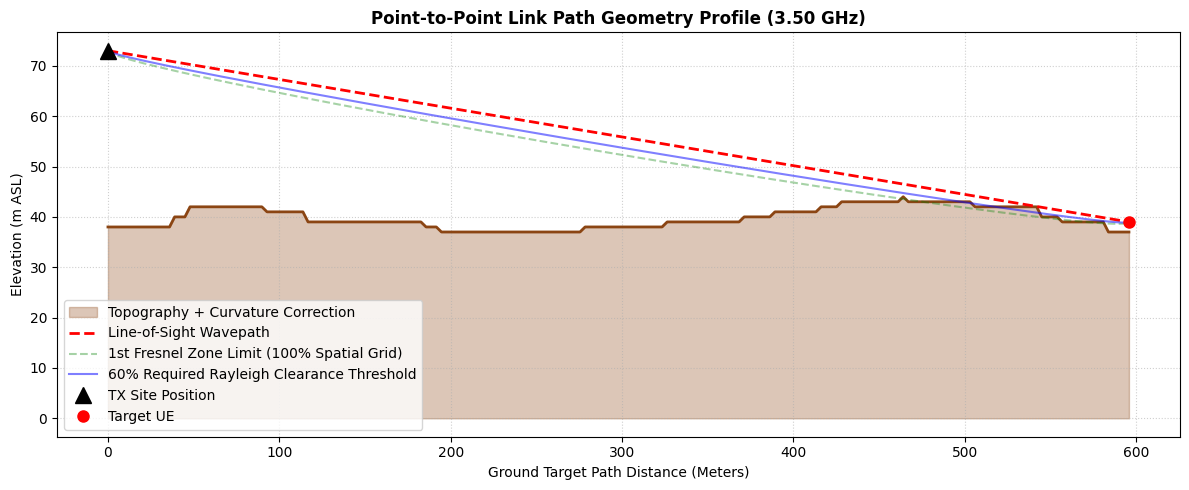

In [8]:
# ==========================================
# 7. PLOT 2: SPATIAL LINK & FRESNEL COMPLETENESS (NO FUNCTIONS)
# ==========================================
num_samples = 200
xp = np.linspace(obs_x, target_x, num_samples)
yp = np.linspace(obs_y, target_y, num_samples)
dist_profile = np.sqrt((xp - obs_x)**2 + (yp - obs_y)**2)
total_profile_dist = dist_profile[-1]

# Clean, functional-less grid sampling matrix
cols_sampled = ((xp - dem_gt[0]) / dem_gt[1]).astype(int)
rows_sampled = ((yp - dem_gt[3]) / dem_gt[5]).astype(int)
    
# Clip sampled markers to absolute index sizes to safely avoid indexing faults
cols_sampled = np.clip(cols_sampled, 0, dem_cols - 1)
rows_sampled = np.clip(rows_sampled, 0, dem_rows - 1)
terrain_profile = dem_full[rows_sampled, cols_sampled]

# Earth curvature modeling transformations
R_e = 6371000.0 * (4.0 / 3.0) 
earth_curvature = (dist_profile * (total_profile_dist - dist_profile)) / (2 * R_e)
terrain_profile_corrected = terrain_profile + earth_curvature

tower_elevation_asl = terrain_profile[0] + obs_height
user_elevation_asl = terrain_profile[-1] + target_height
ray_los = np.linspace(tower_elevation_asl, user_elevation_asl, num_samples)

d1_km = dist_profile / 1000.0
d2_km = (total_profile_dist - dist_profile) / 1000.0
with np.errstate(divide='ignore', invalid='ignore'):
    fresnel_radius = 17.32 * np.sqrt((d1_km * d2_km) / (f_ghz * (total_profile_dist / 1000.0)))
fresnel_radius = np.nan_to_num(fresnel_radius)

plt.figure(figsize=(12, 5))
plt.fill_between(dist_profile, terrain_profile_corrected, color='saddlebrown', alpha=0.3, label='Topography + Curvature Correction')
plt.plot(dist_profile, terrain_profile_corrected, 'saddlebrown', linewidth=2)
plt.plot(dist_profile, ray_los, 'r--', linewidth=2, label='Line-of-Sight Wavepath')
    
# Structural Restoration: Faint green 100% Fresnel Boundary
plt.plot(dist_profile, ray_los - fresnel_radius, 'g--', alpha=0.35, label='1st Fresnel Zone Limit (100% Spatial Grid)')
plt.plot(dist_profile, ray_los - 0.6 * fresnel_radius, 'b-', alpha=0.5, label='60% Required Rayleigh Clearance Threshold')
    
plt.plot(0, tower_elevation_asl, 'k^', markersize=12, label='TX Site Position')
plt.plot(total_profile_dist, user_elevation_asl, 'ro', markersize=8, label='Target UE')
plt.title(f"Point-to-Point Link Path Geometry Profile ({f_ghz:.2f} GHz)", fontsize=12, fontweight='bold')
plt.xlabel("Ground Target Path Distance (Meters)")
plt.ylabel("Elevation (m ASL)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig("telecom_5g_rooftop_fresnel.png", dpi=300)
plt.show()

### 🗺️ Visualization: Ray-Terrain Vector Wave-Interaction Map

This final processing block utilizes advanced surface derivatives to model how emitted RF vectors physically interact with the surrounding topography, exporting the structural analysis to `telecom_5g_rooftop_shadows.png`.

* **In-Memory Surface Derivative Extraction:** Employs `gdal.DEMProcessing` inside temporary virtual memory paths (`/vsimem/`) to eliminate physical disk I/O bottlenecks. It derives continuous slope ($\theta_{\text{slope}}$) and aspect ($\phi_{\text{aspect}}$) raster matrices from the aligned DEM while enforcing edge-pixel interpolation strategies.
* **Incident Wave Vector Calculus:** Computes the exact 3D interaction profile between arriving ray fronts and localized terrain faces. It derives the horizontal path azimuth ($\alpha_{\text{ray}}$) using an optimized modulo wrap and resolves the true structural incidence angle ($\psi_{\text{incidence}}$) across dimension-aligned submatrices via:

$$\alpha_{\text{ray}} = \operatorname{atan2}(X_{\text{sub}} - x_{\text{obs}}, Y_{\text{sub}} - y_{\text{obs}}) \pmod{2\pi}$$


$$\sin(\psi_{\text{incidence}}) = \sin(\theta_{\text{slope}}) \cdot \cos(\phi_{\text{aspect}} - \alpha_{\text{ray}})$$


* **Categorical Wave Interaction Zoning:** Leverages multi-condition NumPy selection arrays to categorize pixels within the $2\text{ km}$ maximum analysis radius into three critical RF interaction classes:
1. **Forward Scattering ($1$):** Shallow grazing incidence ($0^\circ < \psi_{\text{incidence}} \le 15^\circ$) where signals bounce forward along the ground.
2. **Direct Reflection ($2$):** High incident impact ($\psi_{\text{incidence}} > 15^\circ$) generating strong backscatter and signal reversals.
3. **Topographic Shadow Blind Spot ($3$):** Blocked geometry ($\psi_{\text{incidence}} \le 0^\circ$ or falling completely within a non-line-of-sight viewshed block).


* **Geospatial Overlay Output:** Employs resource context managers (`with` blocks) for automated garbage collection and uses a custom categorical discrete color map (`ListedColormap`) to superimpose these interaction behaviors over an OpenStreetMap basemap.

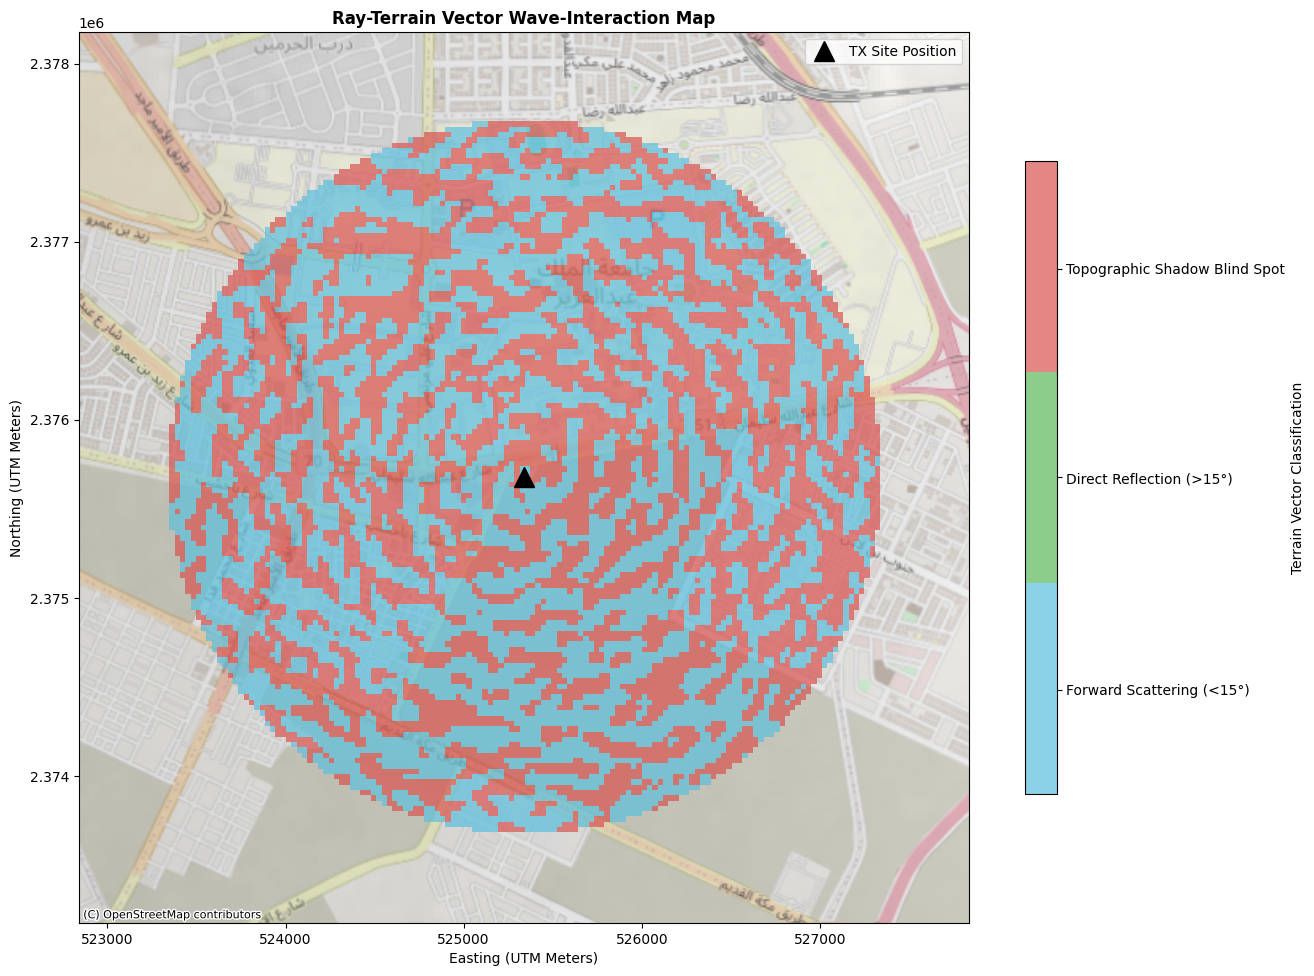

In [9]:
# ==========================================
# 8. PLOT 3: TOPOGRAPHIC INTERACTION MAP
# ==========================================
slope_tif, aspect_tif = "temp_slope.tif", "temp_aspect.tif"
gdal.DEMProcessing(slope_tif, utm_dem_path, "slope", computeEdges=True)
gdal.DEMProcessing(aspect_tif, utm_dem_path, "aspect", computeEdges=True)

slope_ds = gdal.Open(slope_tif)
aspect_ds = gdal.Open(aspect_tif)

# Validated dimension alignment variables (v_cols, v_rows)
slope_rad = np.radians(slope_ds.GetRasterBand(1).ReadAsArray(x_off, y_off, v_cols, v_rows))
aspect_rad = np.radians(aspect_ds.GetRasterBand(1).ReadAsArray(x_off, y_off, v_cols, v_rows))

# Match exact geometry constraints from the sliced inputs to prevent edge broadcasting anomalies
curr_rows, curr_cols = slope_rad.shape
X_sub = X[:curr_rows, :curr_cols]
Y_sub = Y[:curr_rows, :curr_cols]
view_sub = view_data[:curr_rows, :curr_cols]
dist_sub = dist_2d[:curr_rows, :curr_cols]

ray_azimuth = np.arctan2(X_sub - obs_x, Y_sub - obs_y)
ray_azimuth = np.where(ray_azimuth < 0, ray_azimuth + 2 * np.pi, ray_azimuth)
angle_difference = aspect_rad - ray_azimuth
cosine_incidence = np.sin(slope_rad) * np.cos(angle_difference)
incidence_deg = np.degrees(np.arcsin(np.clip(cosine_incidence, -1.0, 1.0)))

interaction_zones = np.select(
        [(incidence_deg > 0) & (incidence_deg <= 15),
         (incidence_deg > 15),
         (incidence_deg <= 0) | (view_sub == 0)],
        [1, 2, 3], default=np.nan)
interaction_zones = np.where(dist_sub <= max_distance_m, interaction_zones, np.nan)

fig, ax = plt.subplots(figsize=(13, 10))
ax.set_xlim(bbox[0], bbox[2])
ax.set_ylim(bbox[1], bbox[3])
    
cx.add_basemap(ax, crs=dem_srs.ExportToProj4(), source=cx.providers.OpenStreetMap.Mapnik, alpha=0.7)
ax.imshow(dem_masked, cmap='gray', extent=dem_extent, alpha=0.15)
    
custom_rf_cmap = ListedColormap(['#5bc0de', '#5cb85c', '#d9534f'])
im = ax.imshow(interaction_zones, cmap=custom_rf_cmap, extent=view_extent, alpha=0.7, vmin=1, vmax=3)
ax.plot(obs_x, obs_y, 'k^', markersize=14, label='TX Site Position')
    
# Categorical Interaction Mapping Legend Elements
cbar_top = plt.colorbar(im, ticks=[1.33, 2.0, 2.66], shrink=0.7)
cbar_top.set_ticklabels(['Forward Scattering (<15°)', 'Direct Reflection (>15°)', 'Topographic Shadow Blind Spot'])
cbar_top.set_label('Terrain Vector Classification')
    
ax.set_title("Ray-Terrain Vector Wave-Interaction Map", fontsize=12, fontweight='bold')
ax.set_xlabel("Easting (UTM Meters)")
ax.set_ylabel("Northing (UTM Meters)")
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig("telecom_5g_rooftop_shadows.png", dpi=300)
plt.show()